## Lab 5
#### Rayan Karki - 022bscit034

In [1]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
def plot(rows, cols, images, titles):
    plt.figure(figsize=(15, 15))
    for i in range(rows):
        for j in range(cols):
            plt.subplot(rows, cols, i * cols + j + 1)
            plt.imshow(images[i*cols+j], cmap='gray')
            plt.title(titles[i*cols+j])

In [5]:
img1 = cv2.imread('img.jpg', 0)
img1 = cv2.resize(img1, (300, 300), interpolation=cv2.INTER_LINEAR)
_, img1 = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)
img1 //= 255

img2 = cv2.imread('image.png', 0)
img2 = cv2.resize(img2, (300, 300), interpolation=cv2.INTER_LINEAR)
_, img2 = cv2.threshold(img2, 60, 255, cv2.THRESH_BINARY)
img2 //= 255

kernel = np.array([[0,1,0],[1,1,1],[0,1,1]], np.uint8)

#### Logical Operations on Binary Images

In [6]:
def operate(img1, img2, operation):
    output = []
    for i in range(len(img1)):
        temp = []
        for j in range(len(img1[0])):
            temp.append(eval(f"{img1[i][j]} {operation} {img2[i][j]}"))
        output.append(temp)
    return np.array(output)

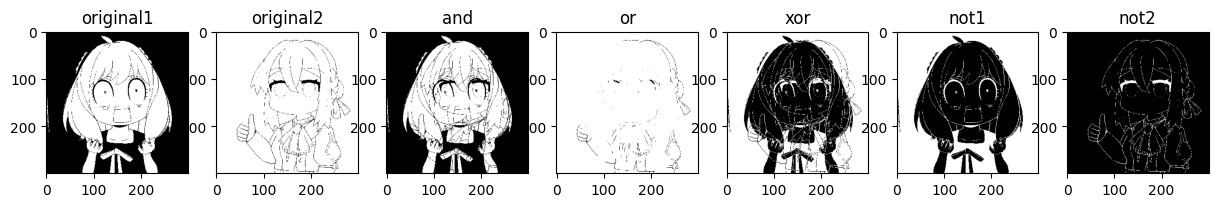

In [7]:
plot(1, 7,[img1, img2, operate(img1, img2, 'and'), operate(img1, img2, 'or'), operate(img1, img2, '^'), 1-img1, 1-img2],
     ['original1', 'original2', 'and','or','xor','not1','not2'])

#### Morphological Operations (Erosion, Dilation, Opening and CLosing)

In [8]:
def erode(img, kernel):
    prep = np.pad(img, 1)
    output = []
    for i in range(1, len(img)+1):
        temp = []
        for j in range(1, len(img[0])+1):
            temp.append(all([prep[i+a-1][j+b-1] or (not kernel[a][b]) for a in range(len(kernel)) for b in range(len(kernel))]))
        output.append(temp)
    return np.array(output)

In [10]:
def dilate(img, kernel):
    prep = np.pad(img, 1)
    output = []
    for i in range(1, len(img)+1):
        temp = []
        for j in range(1, len(img[0])+1):
            temp.append(any([prep[i+a-1][j+b-1] and kernel[a][b] for a in range(len(kernel)) for b in range(len(kernel))]))
        output.append(temp)
    return np.array(output)

In [11]:
def opened(img, kernel):
    return erode(dilate(img, kernel), kernel)

In [12]:
def closed(img, kernel):
    return dilate(erode(img, kernel), kernel)

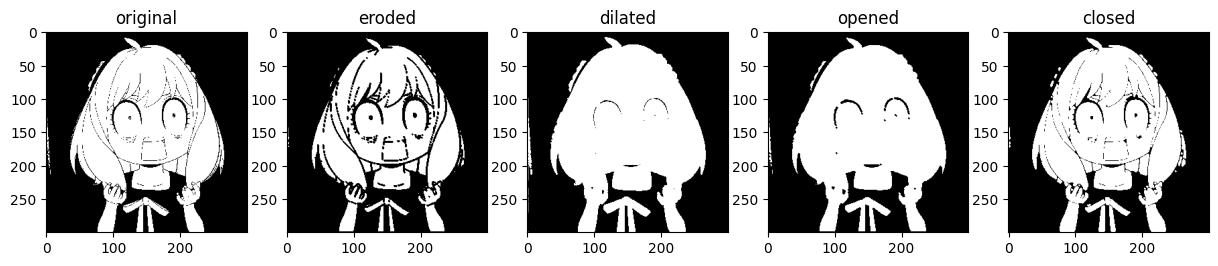

In [13]:
plot(1, 5,[img1, erode(img1, kernel), dilate(img1, kernel), opened(img1, kernel), closed(img1, kernel)],
     ['original','eroded','dilated','opened','closed'])

#### Edge and Boundary detection (point, line and edge)

In [15]:
def hough_lines(img):
    height, width = img.shape
    diag_len = int(np.ceil(np.sqrt(height**2 + width**2)))
    rhos = np.arange(-diag_len, diag_len + 1, 1)
    thetas = np.deg2rad(np.arange(-90, 90, 1))

    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)
    maxIntersection = 0
    y_idxs, x_idxs = np.nonzero(img)

    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]
        for theta_idx in range(len(thetas)):
            theta = thetas[theta_idx]
            rho = int(round(x * np.cos(theta) + y * np.sin(theta)) + diag_len)
            accumulator[rho, theta_idx] += 1
            maxIntersection = max(maxIntersection, accumulator[rho, theta_idx])

    return accumulator, thetas, rhos, maxIntersection

In [16]:
def drawLines(img, accumulator, thetas, rhos, threshold):
    temp = img.copy()
    for i in range(len(accumulator)):
        for j in range(len(accumulator[0])):
            if accumulator[i][j] < threshold: continue
            rho = rhos[i]
            theta = thetas[j]

            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho

            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))

            cv2.line(temp, (x1, y1), (x2, y2), 127)
    return temp


(851, 180)


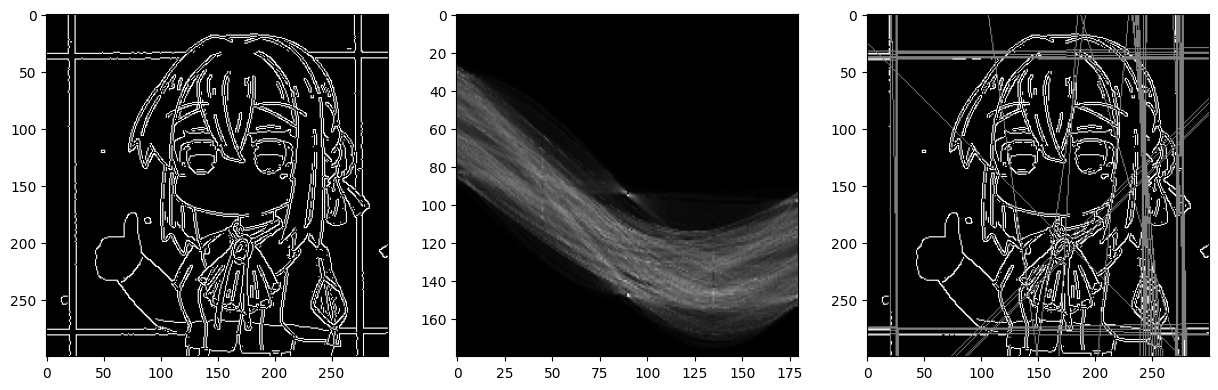

In [18]:
imgFeed = cv2.resize(cv2.imread('image.png'), (300, 300), interpolation=cv2.INTER_LINEAR)
imgFeed = cv2.Canny(imgFeed, threshold1=100, threshold2=200)

accumulator, thetas, rhos, maxIntersection = hough_lines(imgFeed)
# print(accumulator, thetas, rhos)
linesImage = drawLines(imgFeed, accumulator, thetas, rhos, 90)
print(accumulator.shape)

accumulator = (accumulator * 256) // maxIntersection
accumulator = cv2.resize(accumulator.astype(np.uint8), (180, 180))

plt.figure(figsize=(15,6))
plt.subplot(1, 3, 1)
plt.imshow(imgFeed, cmap='gray')
plt.subplot(1, 3, 2)
plt.imshow(accumulator, cmap='gray')
plt.subplot(1, 3, 3)
plt.imshow(linesImage, cmap='gray')

#### Image Segmentation (thresholding, region growing, splitting and merging)

In [19]:
def threshold_segmentation(img, thresh_val=127):
    _, binary = cv2.threshold(img, thresh_val, 255, cv2.THRESH_BINARY)
    return binary

In [20]:
def region_growing(img, seed, threshold=5):
    height, width = img.shape
    segmented = np.zeros_like(img)
    visited = np.zeros_like(img, dtype=bool)
    
    seed_val = img[seed]
    stack = [seed]

    while stack:
        x, y = stack.pop()
        if visited[x, y]:
            continue
        visited[x, y] = True

        if abs(int(img[x, y]) - int(seed_val)) < threshold:
            segmented[x, y] = 255
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < height and 0 <= ny < width and not visited[nx, ny]:
                        stack.append((nx, ny))
    return segmented


In [22]:
def split(img, min_size=16, std_thresh=15):
    h, w = img.shape
    segmented = np.zeros_like(img)

    def split_rec(x, y, width, height):
        region = img[y:y+height, x:x+width]
        if region.size == 0:
            return
        std = np.std(region)
        if std < std_thresh or width <= min_size or height <= min_size:
            segmented[y:y+height, x:x+width] = np.mean(region)
        else:
            half_w, half_h = width // 2, height // 2
            split_rec(x, y, half_w, half_h)
            split_rec(x + half_w, y, width - half_w, half_h)
            split_rec(x, y + half_h, half_w, height - half_h)
            split_rec(x + half_w, y + half_h, width - half_w, height - half_h)
    split_rec(0, 0, w, h)
    return segmented


In [23]:
def merge_regions(segmented, similarity_thresh=10):
    # Very basic merging of neighboring pixels with close intensity
    h, w = segmented.shape
    merged = segmented.copy()

    for y in range(1, h - 1):
        for x in range(1, w - 1):
            neighbors = segmented[y-1:y+2, x-1:x+2].flatten()
            avg = np.mean(neighbors)
            if np.abs(segmented[y, x] - avg) < similarity_thresh:
                merged[y, x] = avg
    return merged


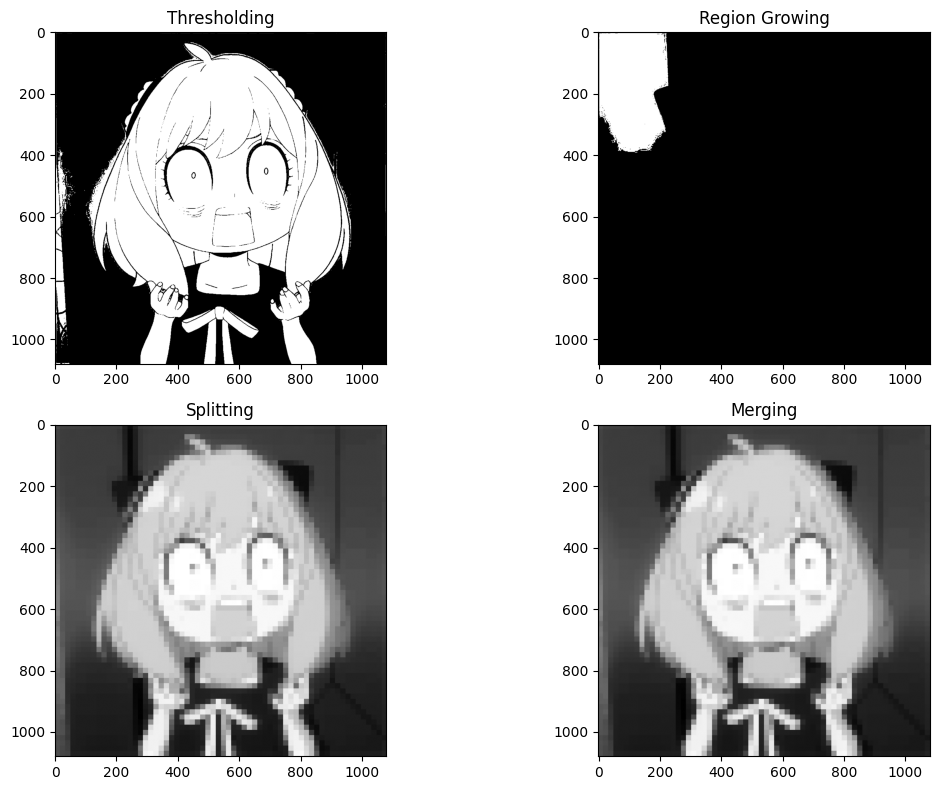

In [ ]:
img = cv2.imread('img.jpg', 0)

# Thresholding
thresh_img = threshold_segmentation(img, 100)

# Region Growing
seed = (100, 50)
region_img = region_growing(img, seed, threshold=10)

# Splitting and Merging
split_img = split(img,32,2)
merged_img = merge_regions(split_img)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1), plt.imshow(thresh_img, cmap='gray'), plt.title('Thresholding')
plt.subplot(2, 2, 2), plt.imshow(region_img, cmap='gray'), plt.title('Region Growing')
plt.subplot(2, 2, 3), plt.imshow(split_img, cmap='gray'), plt.title('Splitting')
plt.subplot(2, 2, 4), plt.imshow(merged_img, cmap='gray'), plt.title('Merging')
plt.tight_layout()
plt.show()
